# Patient Correlation Network with Graph Laplacian Features

Compute pairwise patient similarity matrices from sliding-window glucose curves,
then replace the `SymmetricMatrixBasis` representation with a fixed patient graph
and a Laplacian eigenbasis.

**Pipeline:**
1. Load CGM data and compute per-patient sliding-window average curves $x_i(t)$
2. Build patient-to-patient similarity matrices $S(t) \in \mathbb{R}^{N \times N}$
3. Construct a fixed patient graph from the time-averaged similarity matrix
4. Project each $S(t)$ as a graph signal onto a `GraphLaplacianBasis`
5. Bin in time, fit the temporal GMM with MMD, and reconstruct cluster means
6. Visualize the learned patient graph, cluster-mean heatmaps, and network snapshots


In [2]:
import os
import sys

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import torch
from matplotlib.lines import Line2D
from matplotlib.patches import Ellipse, Patch
from scipy.spatial.distance import pdist, squareform

sys.path.insert(0, os.path.abspath(".."))

from examples.train_glucodensity_temporal import (
    CONTROL_IDS,
    TREATMENT_IDS,
    load_and_preprocess_cgm,
    run_experiment,
)
from examples.train_glucodensity_correlation_graph import (
    build_temporal_coefficients,
    estimate_sigma_median_heuristic,
    threshold_to_adjacency,
)
from src import GaussianKernel, GraphLaplacianBasis
from src.spaces import H1CosineBasis, L2CosineBasis
from src.temporal_mixture import BasisLogitsTimeWeights, NeuralODETimeWeights


In [3]:
# ---- Configuration ----
WINDOW_SIZE = 21
STRIDE = 1
MIN_PATIENT_PRESENCE = 0.4
N_TIME_BINS = 10
N_COMPONENTS = 3

# ---- Graph/Laplacian representation ----
GRAPH_EDGE_PERCENTILE = 85     # keep strongest 15% of average patient similarities
R_GRAPH = 4                 # None = full Laplacian basis
GRAPH_ALPHA = 1.0
NORMALIZED_LAPLACIAN = False

# ---- Temporal mixture model ----
EPOCHS = 200
LR = 0.01
MODEL_TYPE = "basis"          # "basis" or "ode"
R_PI = 3
ODE_HIDDEN = 16
SIGMA_MULT = 4.0
SEED = 42
DATA_PATH = "../data/glucodensities/cgm_all_patients.csv"

# ---- Snapshot-network visualisation ----
EDGE_THRESHOLD_PERCENTILE = 2  # top % of within-window similarities to draw as edges

# ---- Curve-space metric used before building patient similarity ----
# "l2"  -> standard L² distance between glucose curves
# "h1"  -> Sobolev H¹ distance, also penalising slope differences
SPACE_METRIC = "h1"
R_S = 16

torch.manual_seed(SEED)
np.random.seed(SEED)
device = torch.device("cpu")
dtype = torch.float64


## 1. Load CGM data and compute per-patient sliding-window curves


In [4]:
patient_data = load_and_preprocess_cgm(csv_path=DATA_PATH, verbose=True)
print(f"\nPatients loaded: {len(patient_data)}")

N_SLOTS = 288
patient_window_curves = {}   # pid -> {window_start: avg_curve(288,)}

for pid, days_matrix in patient_data.items():
    n_days = days_matrix.shape[0]
    pw = {}
    for w in range(0, n_days - WINDOW_SIZE + 1, STRIDE):
        window = days_matrix[w : w + WINDOW_SIZE]
        avg_curve = np.nanmean(window, axis=0)

        nan_mask = np.isnan(avg_curve)
        if nan_mask.all():
            continue
        if nan_mask.any():
            valid_idx = np.where(~nan_mask)[0]
            avg_curve = np.interp(np.arange(N_SLOTS), valid_idx, avg_curve[valid_idx])

        pw[w] = avg_curve

    if pw:
        patient_window_curves[pid] = pw

n_win = [len(v) for v in patient_window_curves.values()]
print(f"Patients with valid windows: {len(patient_window_curves)}")
print(
    f"Windows per patient: min={min(n_win)}, max={max(n_win)}, "
    f"median={int(np.median(n_win))}"
)


  Total days: 23760 → after rule 1 (prop_missing ≤ 0.2): 22772
  After value clipping & patient block filter: 22771 days, 98 patients
  Patients removed: 1

Patients loaded: 98
Patients with valid windows: 95
Windows per patient: min=26, max=345, median=231


## 2. Build patient similarity matrices over time

Distance metric is controlled by `SPACE_METRIC` in the config cell.
The graph/Laplacian step happens *after* these patient-level similarity matrices are built.


In [5]:
all_w = sorted({w for pw in patient_window_curves.values() for w in pw})

w_pids = {w: set() for w in all_w}
for pid, pw in patient_window_curves.items():
    for w in pw:
        w_pids[w].add(pid)

n_total_w = len(all_w)
patient_pres = {
    pid: sum(1 for w in all_w if pid in w_pids[w]) / n_total_w
    for pid in patient_window_curves
}
common_pids = sorted(pid for pid, frac in patient_pres.items() if frac >= MIN_PATIENT_PRESENCE)
N_pat = len(common_pids)
pid_to_idx = {pid: i for i, pid in enumerate(common_pids)}

valid_w = [w for w in all_w if all(pid in w_pids[w] for pid in common_pids)]
t_indices = np.array([w + (WINDOW_SIZE - 1) / 2.0 for w in valid_w])

ctrl_set, treat_set = set(CONTROL_IDS), set(TREATMENT_IDS)
n_ctrl = sum(1 for pid in common_pids if pid in ctrl_set)
n_treat = sum(1 for pid in common_pids if pid in treat_set)
print(
    f"Common patients (>={MIN_PATIENT_PRESENCE:.0%} presence): {N_pat}  "
    f"(Control: {n_ctrl}, Treatment: {n_treat})"
)
print(f"Valid windows (all common present): {len(valid_w)} / {len(all_w)}")

basis_cls = L2CosineBasis if SPACE_METRIC == "l2" else H1CosineBasis
curve_basis = basis_cls(T=1.0, R=R_S, grid_size=N_SLOTS, d=1, device=device, dtype=dtype)
print(f"\nCurve metric: {SPACE_METRIC.upper()}  (R_S={R_S} cosine modes)")

pairwise_distances = np.zeros((len(valid_w), N_pat, N_pat))
for idx, w in enumerate(valid_w):
    curves_raw = np.stack([patient_window_curves[pid][w] for pid in common_pids])
    curves_t = torch.tensor(curves_raw, device=device, dtype=dtype).unsqueeze(-1)
    with torch.no_grad():
        coeffs = curve_basis.project(curves_t).cpu().numpy()
    pairwise_distances[idx] = squareform(pdist(coeffs, metric="euclidean"))

global_max_dist = pairwise_distances.max()
sim_matrices = 1.0 - pairwise_distances / (global_max_dist + 1e-10)

off_diag_sim = sim_matrices[:, ~np.eye(N_pat, dtype=bool)]
print(f"\nSimilarity matrices: {sim_matrices.shape}")
print(
    f"Similarity stats: min={off_diag_sim.min():.3f}, "
    f"median={np.median(off_diag_sim):.3f}, max={off_diag_sim.max():.3f}"
)


Common patients (>=40% presence): 76  (Control: 25, Treatment: 51)
Valid windows (all common present): 141 / 345

Curve metric: H1  (R_S=16 cosine modes)

Similarity matrices: (141, 76, 76)
Similarity stats: min=0.000, median=0.582, max=0.909


## 3. Build a fixed patient graph and project matrices with a Laplacian basis

Instead of embedding each $S(t)$ in `Sym(N)` with `SymmetricMatrixBasis`,
we build a fixed patient graph from the time-averaged similarity matrix and treat
$S(t)$ as a vector-valued graph signal of shape `(patients, patients)`.


In [6]:
avg_sim = sim_matrices.mean(axis=0)
np.fill_diagonal(avg_sim, 0.0)

avg_off_diag = avg_sim[~np.eye(N_pat, dtype=bool)]
graph_threshold = np.percentile(avg_off_diag, GRAPH_EDGE_PERCENTILE)
edge_mask = threshold_to_adjacency(avg_sim, threshold=graph_threshold, absolute=False)
graph_weights = avg_sim * edge_mask
n_edges = int(np.count_nonzero(np.triu(edge_mask, k=1)))

graph_rank = N_pat if R_GRAPH is None else min(R_GRAPH, N_pat)
graph_basis = GraphLaplacianBasis.from_adjacency(
    adjacency=torch.tensor(graph_weights, device=device, dtype=dtype),
    alpha=GRAPH_ALPHA,
    num_eigenvectors=graph_rank,
    normalized=NORMALIZED_LAPLACIAN,
    device=device,
    dtype=dtype,
)

sim_t = torch.tensor(sim_matrices, device=device, dtype=dtype)
coeffs_all = graph_basis.project(sim_t).detach().cpu().numpy()

print(f"Graph threshold ({GRAPH_EDGE_PERCENTILE}th percentile): {graph_threshold:.3f}")
print(f"Graph edges retained: {n_edges}")
print(f"Graph basis rank: {graph_rank}")
print(f"Projected coefficient shape: {coeffs_all.shape}")
print("First Laplacian eigenvalues:", np.round(graph_basis.eigenvalues.cpu().numpy()[:10], 4))


Graph threshold (85th percentile): 0.652
Graph edges retained: 428
Graph basis rank: 4
Projected coefficient shape: (141, 304)
First Laplacian eigenvalues: [-0. -0. -0. -0.]


## 4. Temporal binning and temporal GMM fit


In [7]:
rep = build_temporal_coefficients(
    coeffs=coeffs_all,
    t_indices=t_indices,
    n_time_bins=N_TIME_BINS,
    device=device,
    dtype=dtype,
    verbose=True,
)
X_time, t_grid, mask = rep["X_time"], rep["t_grid"], rep["mask"]

sigma_auto = estimate_sigma_median_heuristic(X_time, mask)
sigma = max(1e-8, sigma_auto * SIGMA_MULT)
print(f"Kernel sigma: auto={sigma_auto:.4f}, final={sigma:.4f}")
kernel = GaussianKernel(sigma=sigma)


  Temporal binning: 10 requested, 10 non-empty
  Day range: [10.0, 150.0]
  Bin sizes: min=14, max=15, median=14
  Padded to n_max=15, coeff_dim=304
Kernel sigma: auto=24.5499, final=98.1994


In [8]:
if MODEL_TYPE == "basis":
    time_basis = L2CosineBasis(
        T=1.0, R=R_PI, grid_size=rep["L_t"], d=1, device=device, dtype=dtype
    )
    twm = BasisLogitsTimeWeights(
        basis_matrix=time_basis.Phi,
        num_components=N_COMPONENTS,
        device=device,
        dtype=dtype,
    )
    model_name = "PatientGraphBasis"
else:
    twm = NeuralODETimeWeights(
        t_grid=t_grid,
        num_components=N_COMPONENTS,
        hidden_dim=ODE_HIDDEN,
        device=device,
        dtype=dtype,
    )
    model_name = "PatientGraphODE"

print(f"Training {model_name} ({EPOCHS} epochs)...")
model, history, pi_t = run_experiment(
    name=model_name,
    time_weight_model=twm,
    X_time=X_time,
    kernel=kernel,
    n_components=N_COMPONENTS,
    coeff_dim=rep["coeff_dim"],
    num_epochs=EPOCHS,
    lr=LR,
    device=device,
    dtype=dtype,
    mask=mask,
    verbose=True,
)


Training PatientGraphBasis (200 epochs)...
Epoch   25/200: MMD²(avg_t) = 0.027290
Epoch   50/200: MMD²(avg_t) = 0.023009
Epoch   75/200: MMD²(avg_t) = 0.019995
Epoch  100/200: MMD²(avg_t) = 0.017567
Epoch  125/200: MMD²(avg_t) = 0.015735
Epoch  150/200: MMD²(avg_t) = 0.014470
Epoch  175/200: MMD²(avg_t) = 0.013622
Epoch  200/200: MMD²(avg_t) = 0.013063
PatientGraphBasis final MMD²(avg_t): 0.013063
PatientGraphBasis mean pi over t: [0.25072163 0.34646442 0.40281396]


## 5. Reconstruct cluster means and inspect the learned patient graph


/tmp/ipykernel_74403/1189192060.py:49: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


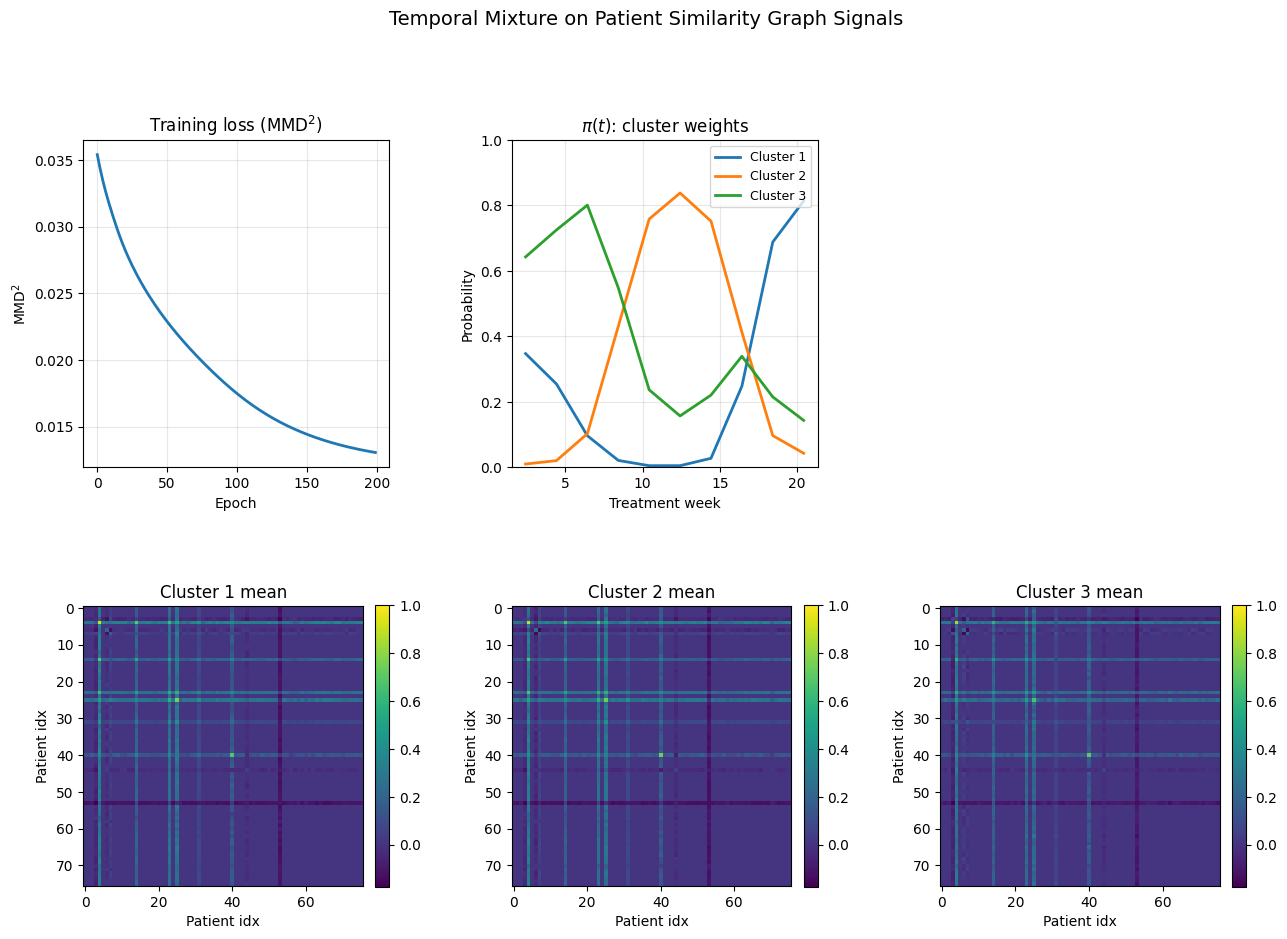

In [9]:
with torch.no_grad():
    means_coeff = model.mean.cpu()

means_orig = means_coeff * rep["coeff_std"].cpu() + rep["coeff_mean"].cpu()
recon_means = graph_basis.reconstruct(means_orig, d=N_pat)
recon_means = 0.5 * (recon_means + recon_means.transpose(1, 2))
recon_means_np = recon_means.detach().numpy()

pi_t_np = pi_t.cpu().numpy()
t_np = t_grid.detach().cpu().numpy()
day_range = rep["t_max_days"] - rep["t_min_days"]
t_days = t_np * day_range + rep["t_min_days"]
use_weeks = t_days.max() > 30
t_axis = t_days / 7.0 if use_weeks else t_days
t_label = "Treatment week" if use_weeks else "Treatment day"
K = N_COMPONENTS

fig = plt.figure(figsize=(5 * max(K, 2), 10))
gs = fig.add_gridspec(2, max(K, 2), hspace=0.35, wspace=0.4)

ax0 = fig.add_subplot(gs[0, 0])
ax0.plot(history, lw=2, color="tab:blue")
ax0.set_title("Training loss (MMD$^2$)")
ax0.set_xlabel("Epoch")
ax0.set_ylabel("MMD$^2$")
ax0.grid(alpha=0.3)

ax1 = fig.add_subplot(gs[0, 1])
for k in range(K):
    ax1.plot(t_axis, pi_t_np[:, k], lw=2, label=f"Cluster {k + 1}")
ax1.set_title(r"$\pi(t)$: cluster weights")
ax1.set_xlabel(t_label)
ax1.set_ylabel("Probability")
ax1.set_ylim(0, 1)
ax1.legend(fontsize=9)
ax1.grid(alpha=0.3)

vmin = min(recon_means_np.min(), sim_matrices.min())
vmax = max(recon_means_np.max(), sim_matrices.max())
for k in range(K):
    ax = fig.add_subplot(gs[1, k])
    im = ax.imshow(recon_means_np[k], cmap="viridis", aspect="equal", vmin=vmin, vmax=vmax)
    ax.set_title(f"Cluster {k + 1} mean")
    ax.set_xlabel("Patient idx")
    ax.set_ylabel("Patient idx")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.suptitle("Temporal Mixture on Patient Similarity Graph Signals", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


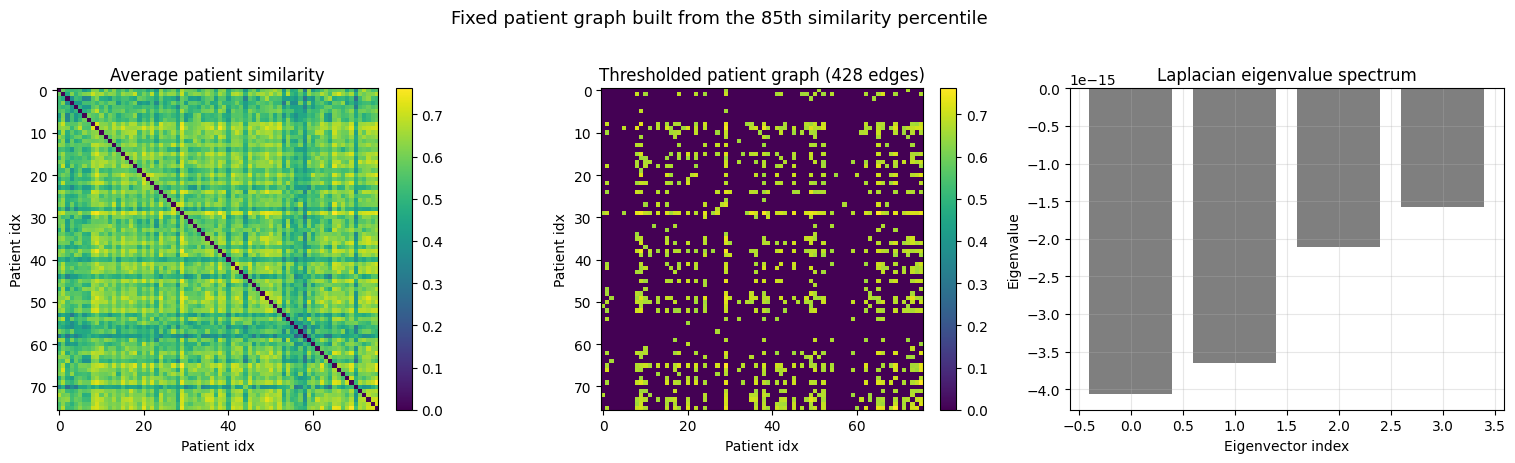

In [10]:
eigenvalues_np = graph_basis.eigenvalues.cpu().numpy()

fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

im0 = axes[0].imshow(avg_sim, cmap="viridis", aspect="equal")
axes[0].set_title("Average patient similarity")
axes[0].set_xlabel("Patient idx")
axes[0].set_ylabel("Patient idx")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(graph_weights, cmap="viridis", aspect="equal")
axes[1].set_title(f"Thresholded patient graph ({n_edges} edges)")
axes[1].set_xlabel("Patient idx")
axes[1].set_ylabel("Patient idx")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

axes[2].bar(np.arange(len(eigenvalues_np)), eigenvalues_np, color="tab:gray")
axes[2].set_title("Laplacian eigenvalue spectrum")
axes[2].set_xlabel("Eigenvector index")
axes[2].set_ylabel("Eigenvalue")
axes[2].grid(alpha=0.3)

fig.suptitle(
    f"Fixed patient graph built from the {GRAPH_EDGE_PERCENTILE}th similarity percentile",
    fontsize=13,
    y=1.02,
)
plt.tight_layout()
plt.show()


## 6. Network snapshots across time

The temporal GMM is fit in graph-Laplacian coefficient space, but we can still inspect
raw patient similarity networks at selected windows.


/tmp/ipykernel_74403/2547290786.py:168: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


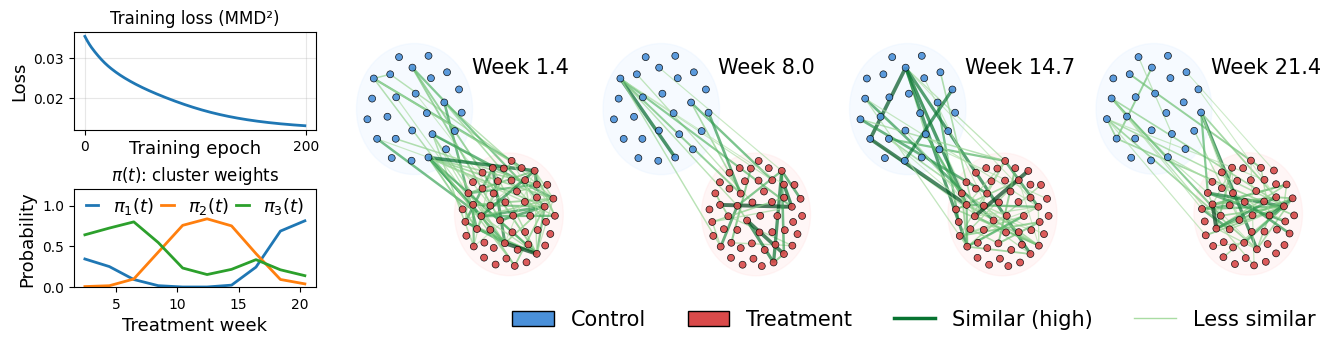

In [13]:
ctrl_indices = [pid_to_idx[p] for p in common_pids if p in ctrl_set]
treat_indices = [pid_to_idx[p] for p in common_pids if p in treat_set]
communities = [comm for comm in (ctrl_indices, treat_indices) if comm]

layout_weights = graph_weights.copy()
if np.count_nonzero(layout_weights) == 0:
    layout_weights = avg_sim.copy()
np.fill_diagonal(layout_weights, 0.0)
G_full = nx.from_numpy_array(layout_weights)

if len(communities) >= 2:
    supergraph = nx.path_graph(len(communities))
    superpos = nx.spring_layout(supergraph, scale=1, seed=SEED)
    centers = [superpos[i] for i in range(len(communities))]
    pos = {}
    for center, comm in zip(centers, communities):
        subg = G_full.subgraph(comm)
        uniform_subg = nx.complete_graph(comm)
        pos.update(
            nx.spring_layout(
                uniform_subg,
                center=center,
                seed=SEED,
                weight=None,
                k=1.5 / max(np.sqrt(len(comm)), 1),
            )
        )
else:
    pos = nx.spring_layout(
        G_full,
        seed=SEED,
        weight=None,
        k=2.5 / max(np.sqrt(N_pat), 1),
        iterations=200,
    )

node_colors = []
for pid in common_pids:
    if pid in ctrl_set:
        node_colors.append("#4A90D9")
    elif pid in treat_set:
        node_colors.append("#D94A4A")
    else:
        node_colors.append("#999999")

off_diag_sim_all = sim_matrices[:, ~np.eye(N_pat, dtype=bool)]
EDGE_THRESHOLD_PERCENTILE = 2
threshold = np.percentile(off_diag_sim_all, 100 - EDGE_THRESHOLD_PERCENTILE)
n_graph_times = 4
graph_indices = np.linspace(0, len(valid_w) - 1, n_graph_times, dtype=int)

fig = plt.figure(figsize=(16, 3.5))
outer = fig.add_gridspec(2, 2, width_ratios=(1.0, 4.0), hspace=0.6, wspace=0.05)

ax_loss = fig.add_subplot(outer[0, 0])
ax_loss.plot(history, lw=2, color="tab:blue")
ax_loss.set_xticks([0,200])
ax_loss.set_title("Training loss (MMD²)")
ax_loss.set_ylabel("Loss", fontsize=13)
ax_loss.set_xlabel("Training epoch", fontsize=13, labelpad=-10)
ax_loss.grid(alpha=0.3)

ax_pi = fig.add_subplot(outer[1, 0])
import matplotlib
cmap = matplotlib.colormaps.get_cmap("Purples")
for k in range(K):
    ax_pi.plot(t_axis, pi_t_np[:, k], lw=2, label=f"$\pi_{{{k + 1}}}(t)$") #, color=cmap((1+k)/K))
ax_pi.set_title(r"$\pi(t)$: cluster weights")
ax_pi.set_xlabel(t_label, fontsize=13)
ax_pi.set_ylabel("Probability", fontsize=13)
ax_pi.set_ylim(0, 1.2)
ax_pi.grid(alpha=0.0)
ax_pi.legend(
    fontsize=13, 
    frameon=False, 
    ncols=3, 
    columnspacing=0.4, 
    loc="upper center", 
    bbox_to_anchor=(0.5, 1.1),
    handlelength=0.7
)

graph_gs = outer[:, 1].subgridspec(1, n_graph_times, wspace=0.08)
graph_axes = [fig.add_subplot(graph_gs[0, i]) for i in range(n_graph_times)]

for ax, t_idx in zip(graph_axes, graph_indices):
    S = sim_matrices[t_idx]
    t_day = t_indices[t_idx]

    G = nx.Graph()
    G.add_nodes_from(range(N_pat))

    edges, edge_w = [], []
    for i in range(N_pat):
        for j in range(i + 1, N_pat):
            if S[i, j] >= threshold:
                G.add_edge(i, j)
                edges.append((i, j))
                edge_w.append(S[i, j])

    if edge_w:
        ew = np.array(edge_w)
        ew_norm = (ew - ew.min()) / (ew.max() - ew.min() + 1e-9)
        edge_colors = [plt.cm.Greens(0.3 + 0.7 * v) for v in ew_norm]
        edge_widths = 0.8 + 2.0 * ew_norm
    else:
        edge_colors, edge_widths = [], []

    if len(communities) >= 2:
        for comm, bg_color in zip(communities[:2], ("#DDEEFF", "#FFDDDD")):
            comm_pos = np.array([pos[n] for n in comm])
            cx, cy = comm_pos.mean(axis=0)
            rx = comm_pos[:, 0].std() * 2.5 + 0.15
            ry = comm_pos[:, 1].std() * 2.5 + 0.15
            ax.add_patch(
                Ellipse(
                    (cx, cy),
                    width=1.5 * rx,
                    height=1.5 * ry,
                    color=bg_color,
                    alpha=0.25,
                    zorder=0,
                )
            )

    nx.draw_networkx_nodes(
        G,
        pos,
        ax=ax,
        node_color=node_colors,
        node_size=25,
        alpha=0.9,
        edgecolors="black",
        linewidths=0.5,
    )
    if edges:
        nx.draw_networkx_edges(
            G,
            pos,
            ax=ax,
            edgelist=edges,
            edge_color=edge_colors,
            width=edge_widths,
            alpha=0.7,
        )

    title = f"Week {t_day / 7:.1f}" if use_weeks else f"Day {t_day:.0f}"
    ax.text(0.55, 0.9, title, transform=ax.transAxes, fontsize=15, va="top")
    ax.set_axis_off()

legend_elements = [
    Patch(facecolor="#4A90D9", edgecolor="black", label="Control"),
    Patch(facecolor="#D94A4A", edgecolor="black", label="Treatment"),
    Line2D([0], [0], color=plt.cm.Greens(0.85), lw=2.5, label="Similar (high)"),
    Line2D([0], [0], color=plt.cm.Greens(0.35), lw=1.0, label="Less similar"),
]

#fig.text(0.65, 0.9, "Patient Similarity Network", ha="center", fontsize=20)
fig.legend(
    handles=legend_elements,
    loc="upper center",
    bbox_to_anchor=(0.65, 0.1),
    fontsize=15,
    ncols=4,
    frameon=False,
)

plt.tight_layout()
fig.subplots_adjust(top=0.84)
fig.savefig("../paper/images/patient_graph.pdf", dpi=100, bbox_inches="tight")
plt.show()
